<a href="https://colab.research.google.com/github/rakesh-mandal/ML/blob/main/Adaboost/Adaboost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer, make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report


In [6]:
df = load_breast_cancer()
X, y = df.data, df.target

In [8]:
X.shape

(569, 30)

In [5]:
df

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)


In [10]:
# Baseline: a single decision stump (depth=1 tree)
stump = DecisionTreeClassifier(max_depth=1, random_state=42)
stump.fit(X_train, y_train)
stump_acc = accuracy_score(y_test, stump.predict(X_test))

In [11]:
stump_acc

0.9230769230769231

In [12]:
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=1.0,
    random_state=42,
)

In [13]:
ada.fit(X_train, y_train)
ada_acc = accuracy_score(y_test, ada.predict(X_test))
ada_acc

0.965034965034965

In [14]:

from sklearn.model_selection import cross_val_score



np.mean(cross_val_score(ada,X_train,y_train,scoring='accuracy',cv=10))

np.float64(0.969545957918051)

In [15]:
print("=" * 50)
print("Breast Cancer Wisconsin: AdaBoost vs Single Stump")
print("=" * 50)
print(f"Single decision stump accuracy : {stump_acc:.4f}")
print(f"AdaBoost (100 stumps) accuracy : {ada_acc:.4f}")
print()
print("AdaBoost classification report:")
print(classification_report(y_test, ada.predict(X_test), target_names=df.target_names))

Breast Cancer Wisconsin: AdaBoost vs Single Stump
Single decision stump accuracy : 0.9231
AdaBoost (100 stumps) accuracy : 0.9650

AdaBoost classification report:
              precision    recall  f1-score   support

   malignant       0.98      0.92      0.95        53
      benign       0.96      0.99      0.97        90

    accuracy                           0.97       143
   macro avg       0.97      0.96      0.96       143
weighted avg       0.97      0.97      0.96       143



In [20]:
staged_acc = [
    accuracy_score(y_test, pred) for pred in ada.staged_predict(X_test)
]

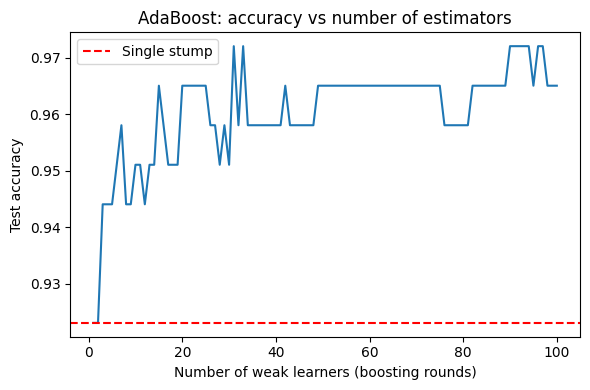

In [22]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(staged_acc) + 1), staged_acc)
plt.axhline(stump_acc, color="red", linestyle="--", label="Single stump")
plt.xlabel("Number of weak learners (boosting rounds)")
plt.ylabel("Test accuracy")
plt.title("AdaBoost: accuracy vs number of estimators")
plt.legend()
plt.tight_layout()
#plt.savefig("/mnt/user-data/outputs/adaboost_staged_accuracy.png", dpi=150)
plt.show()

In [23]:
# ---------------------------------------------------------
# Part 2: make_moons — visualize the decision boundary
# ---------------------------------------------------------
Xm, ym = make_moons(n_samples=300, noise=0.3, random_state=42)
Xm_train, Xm_test, ym_train, ym_test = train_test_split(
    Xm, ym, test_size=0.25, random_state=42
)


In [24]:
Xm.shape

(300, 2)

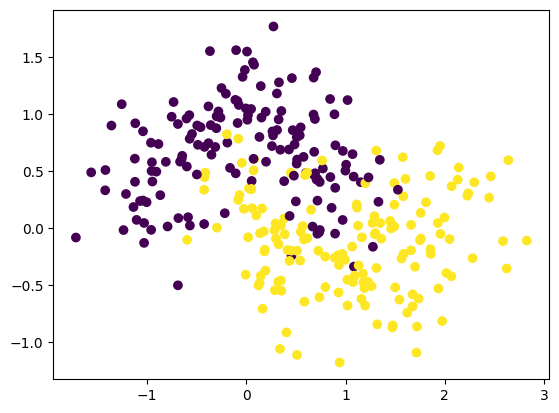

In [26]:
plt.scatter(Xm[:,0],Xm[:,1],c=ym)

In [27]:
Xm_train, Xm_test, ym_train, ym_test = train_test_split(Xm, ym, test_size=0.25, random_state=42)

In [28]:
ada_moons = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=50,
    random_state=42,
)
ada_moons.fit(Xm_train, ym_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                   random_state=42)

In [29]:
moons_acc = accuracy_score(ym_test, ada_moons.predict(Xm_test))

In [30]:
moons_acc

0.9333333333333333

In [31]:
# Plot decision boundary
h = 0.02
x_min, x_max = Xm[:, 0].min() - 0.5, Xm[:, 0].max() + 0.5
y_min, y_max = Xm[:, 1].min() - 0.5, Xm[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

In [33]:
x_min

np.float64(-2.21772879451623)

In [34]:
Z = ada_moons.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

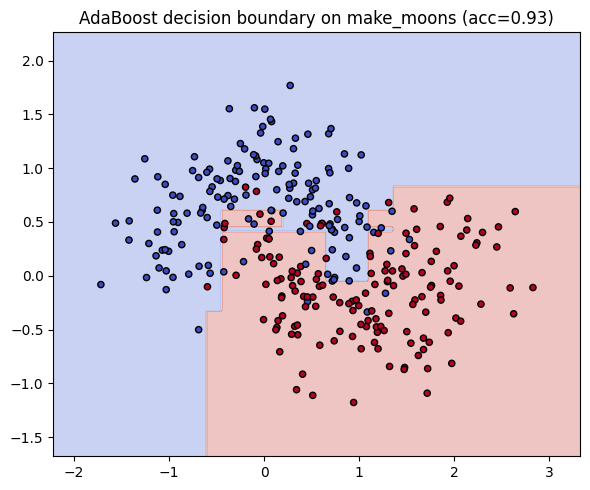

In [35]:
plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
plt.scatter(Xm[:, 0], Xm[:, 1], c=ym, cmap="coolwarm", edgecolors="k", s=20)
plt.title(f"AdaBoost decision boundary on make_moons (acc={moons_acc:.2f})")
plt.tight_layout()
#plt.savefig("/mnt/user-data/outputs/adaboost_moons_boundary.png", dpi=150)
plt.show()

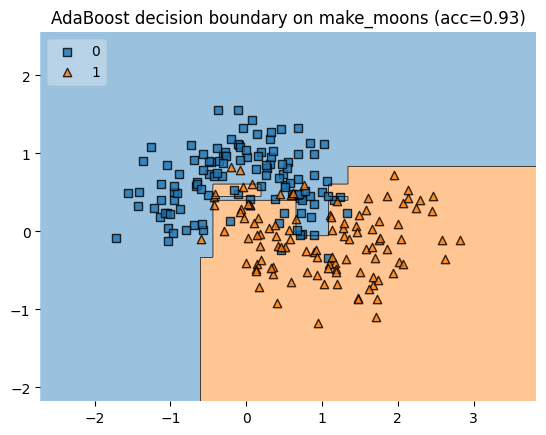

In [36]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(Xm_train, ym_train, clf=ada_moons, legend=2)
plt.title(f"AdaBoost decision boundary on make_moons (acc={moons_acc:.2f})")
plt.show()